# MIRepNet + linear probe vs. convex head - LOSO + K-min calibration sweep

Same leave-one-subject-out (LOSO) + K-trial calibration protocol as
`reve_kmin_convexnn_v4.ipynb`, but the frozen backbone is **MIRepNet**
(staraink/MIRepNet, the first EEG foundation model tailored to motor imagery;
arXiv:2507.20254). Two heads are compared on the frozen 256-d MIRepNet feature:

1. **Linear probe** - multinomial logistic regression on the feature. K=0 is
   trained on the source pool; K>0 refits on `source + calibration` with sample
   weights that give the calibration set a fixed target mass (source-anchored,
   matching the convex head's weighting).
2. **2-stage convex-NN head** - the same warm-started ADMM convex two-layer ReLU
   MLP used for REVE, re-solved on `source + weighted calibration`.

Both are scored on one fixed per-subject eval set (constant across K), with
`N_HELD_OUT=8` subjects chosen at random (SEED=0) and `K_BUDGETS=(0,1,2,5,10)`.

## MIRepNet input-data spec (reverse-engineered from the repo + paper)

| field | value | source |
|---|---|---|
| channel template | **45 channels** (`use_channels_names`): F/FC/C/CP/P rows + FT7/8, T7/8, TP7/8 | `utils/channel_list.py` |
| spatial alignment | map dataset montage -> template (inverse-distance interp for missing). **EEGMMI already contains all 45**, so it is a pure channel selection. | `utils/utils.py:pad_missing_channels_diff` |
| band-pass | **8-30 Hz** | paper §preprocessing |
| sampling rate | **250 Hz** | `dataset.py`, paper |
| window | **4 s = 1000 samples** (first 1000 time points) | `dataset.py` |
| distribution alignment | **Euclidean Alignment** (per-subject whitening by mean covariance) | `utils/utils.py:EA` |
| model | PatchEmbedding (temporal conv -> spatial conv over 45 ch -> avg-pool -> 1x1 proj) -> 6-layer Transformer (emb 256, 8 heads) -> mean-pool over tokens | `model/mlm.py` |
| feature | **256-d** mean-pooled token representation (`pooled`, the 1st output of `forward`) | `model/mlm.py:mlm_mask.forward` |
| weights | `starself/MIRepNet` on HuggingFace, `MIRepNet.pth` (5.2 M params) | README |

Note: our EEGMMI dataset is exactly MIRepNet's `PHYSIONETMI` source, so MIRepNet
was (partly) pretrained on this data distribution - keep that in mind when
reading the numbers (this is an in-distribution probe, not a transfer test).


## 0. Config

In [1]:
from __future__ import annotations

import sys, os, json, time, warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import torch

# --- paths ---
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
EEGMMI_DIR = REPO_ROOT / "data" / "raw" / "eegmmi"
CLD_DIR = REPO_ROOT / "vendor" / "CLD"
MIREPNET_VENDOR = REPO_ROOT / "vendor" / "MIRepNet"
FEAT_CACHE_DIR = REPO_ROOT / "data" / "cache" / "mirepnet_feats"
assert EEGMMI_DIR.exists(), f"missing dataset dir: {EEGMMI_DIR}"
assert CLD_DIR.exists(),    f"missing CLD vendor dir: {CLD_DIR}"
assert (MIREPNET_VENDOR / "mirepnet_model.py").exists(), f"missing vendored MIRepNet model in {MIREPNET_VENDOR}"

# --- sweep config (identical protocol to reve_kmin_convexnn_v4) ---
K_BUDGETS         = (0, 1, 2, 5, 10)       # trials per class used for calibration (K=0 = LOSO)
EVAL_PER_CLASS    = 11                      # fixed held-out eval trials per class (shared by both heads)
N_HELD_OUT        = 8
SEED              = 0
IMAGERY_RUNS      = (4, 6, 8, 10, 12, 14)
EXCLUDED_SUBJECTS = frozenset({88, 89, 92, 100, 104})

# --- MIRepNet preprocessing spec ---
TARGET_FS    = 250
TRIAL_TMIN   = 0.0
TRIAL_TMAX   = 4.0
TRIAL_SAMPLES = int(round((TRIAL_TMAX - TRIAL_TMIN) * TARGET_FS))   # 1000
BANDPASS     = (8.0, 30.0)
FEATURE_DIM  = 256
# 45-channel MIRepNet template (utils/channel_list.py:use_channels_names), upper-cased.
TEMPLATE_CH = [
    "F7", "F5", "F3", "F1", "FZ", "F2", "F4", "F6", "F8",
    "FT7", "FC5", "FC3", "FC1", "FCZ", "FC2", "FC4", "FC6", "FT8",
    "T7", "C5", "C3", "C1", "CZ", "C2", "C4", "C6", "T8",
    "TP7", "CP5", "CP3", "CP1", "CPZ", "CP2", "CP4", "CP6", "TP8",
    "P7", "P5", "P3", "P1", "PZ", "P2", "P4", "P6", "P8",
]
N_CHANNELS = len(TEMPLATE_CH)   # 45

# MIRepNet is small (5.2M params) and runs inference on CPU comfortably; CPU also
# avoids contending with any concurrent MPS training job. Override to "mps"/"cuda"
# if you want and nothing else is using the accelerator.
MIREPNET_DEVICE = "cpu"

# --- ConvexNN head hparams (same as the REVE notebook) ---
CVX_N_NEURONS  = 16
CVX_BETA       = 1.0e-3
CVX_RHO        = 0.1
CVX_ADMM_ITERS = 8
CVX_PCG_ITERS  = 32
CVX_RANK       = 20
STAGE2_ADMM_ITERS = 4
STAGE2_TARGET_MASS = 0.35
STAGE2_WARM_START_DUAL = False

# --- Linear probe hparams ---
LINPROBE_C = 1.0
LINPROBE_MAX_ITER = 2000
LINPROBE_TARGET_MASS = STAGE2_TARGET_MASS   # same source-anchored calibration mass as the convex head

DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"torch device={DEVICE}  mirepnet_device={MIREPNET_DEVICE}  |  repo={REPO_ROOT}")


torch device=mps  mirepnet_device=cpu  |  repo=/Users/williamtan/Projects/cs229/etm_clf


## 1. Load EEGMMI with MIRepNet preprocessing (45-ch template, 8-30 Hz, 250 Hz, EA)

In [2]:
import mne
from scipy.linalg import fractional_matrix_power
mne.set_log_level("ERROR")

RUN_LABEL_MAP = {
    (4, "T1"): 0,  (8, "T1"): 0,  (12, "T1"): 0,
    (4, "T2"): 1,  (8, "T2"): 1,  (12, "T2"): 1,
    (6, "T1"): 2,  (10, "T1"): 2, (14, "T1"): 2,
    (6, "T2"): 3,  (10, "T2"): 3, (14, "T2"): 3,
}
CLASS_NAMES = ("LeftFist", "RightFist", "BothFists", "BothFeet")

@dataclass
class Trial:
    eeg: np.ndarray   # (45, 1000) in the MIRepNet template order; EA is applied later, per subject
    label: int
    subject: int
    run: int
    trial_idx: int

def _norm_ch(name: str) -> str:
    return name.strip().rstrip(".").strip().upper()

def _load_run(edf_path: Path, subject: int, run: int) -> list[Trial]:
    raw = mne.io.read_raw_edf(str(edf_path), preload=True, verbose="ERROR")
    raw.rename_channels({c: _norm_ch(c) for c in raw.ch_names})
    missing = [c for c in TEMPLATE_CH if c not in raw.ch_names]
    if missing:
        raise ValueError(f"missing template channels: {missing}")
    # MIRepNet preprocessing: band-pass 8-30 Hz, resample to 250 Hz.
    raw.filter(BANDPASS[0], BANDPASS[1], fir_design="firwin", verbose="ERROR")
    raw.resample(TARGET_FS, verbose="ERROR")

    events, event_id = mne.events_from_annotations(raw, verbose="ERROR")
    keep_ids = {k: v for k, v in event_id.items() if k in ("T1", "T2") and (run, k) in RUN_LABEL_MAP}
    if not keep_ids:
        return []
    ch_idx = [raw.ch_names.index(c) for c in TEMPLATE_CH]   # select + reorder to template
    tmax = TRIAL_TMAX - 1.0 / raw.info["sfreq"]
    ep = mne.Epochs(raw, events=events, event_id=keep_ids,
                    tmin=TRIAL_TMIN, tmax=tmax, baseline=None, preload=True,
                    reject=None, flat=None, proj=False, verbose="ERROR")
    X = ep.get_data(units="uV", copy=False).astype(np.float32)[:, ch_idx, :]
    if X.shape[-1] > TRIAL_SAMPLES:
        X = X[..., -TRIAL_SAMPLES:]
    elif X.shape[-1] < TRIAL_SAMPLES:
        pad = np.zeros(X.shape[:-1] + (TRIAL_SAMPLES,), dtype=X.dtype)
        pad[..., -X.shape[-1]:] = X
        X = pad
    out = []
    for i, evt in enumerate(ep.events):
        marker = next(k for k, v in keep_ids.items() if v == evt[-1])
        out.append(Trial(eeg=X[i], label=RUN_LABEL_MAP[(run, marker)],
                         subject=subject, run=run, trial_idx=i))
    return out

def load_subject(subject: int) -> list[Trial]:
    if subject in EXCLUDED_SUBJECTS:
        return []
    sd = EEGMMI_DIR / f"S{subject:03d}"
    trials: list[Trial] = []
    for run in IMAGERY_RUNS:
        edf = sd / f"S{subject:03d}R{run:02d}.edf"
        if not edf.exists():
            continue
        try:
            trials.extend(_load_run(edf, subject, run))
        except Exception as e:
            print(f"  [skip] S{subject:03d}R{run:02d}: {type(e).__name__}: {e}")
    return trials

def euclidean_align(X: np.ndarray) -> np.ndarray:
    """Per-set Euclidean Alignment (mirrors MIRepNet utils.EA): whiten each trial
    by R^-1/2 where R is the mean per-trial covariance. Label-free; applied per
    subject so each subject's channels share an (approximately) identity covariance."""
    if len(X) == 0:
        return X
    cov = np.stack([np.cov(X[i]) for i in range(len(X))], axis=0)
    R = cov.mean(axis=0)
    R_inv_sqrt = np.asarray(fractional_matrix_power(R, -0.5).real, dtype=np.float32)
    return np.stack([R_inv_sqrt @ X[i] for i in range(len(X))], axis=0).astype(np.float32)

ALL_SUBJECTS = tuple(s for s in range(1, 110) if s not in EXCLUDED_SUBJECTS)
print(f"{len(ALL_SUBJECTS)} candidate subjects; template C={N_CHANNELS}, T={TRIAL_SAMPLES} "
      f"@ {TARGET_FS} Hz, band-pass {BANDPASS} Hz, per-subject EA")


104 candidate subjects; template C=45, T=1000 @ 250 Hz, band-pass (8.0, 30.0) Hz, per-subject EA


## 2. MIRepNet feature extractor (frozen, 256-d pooled feature)

In [3]:
if str(MIREPNET_VENDOR) not in sys.path:
    sys.path.insert(0, str(MIREPNET_VENDOR))
from mirepnet_model import mlm_mask
from huggingface_hub import hf_hub_download

def build_mirepnet():
    model = mlm_mask(emb_size=256, depth=6, n_classes=4, pretrainmode=False)
    try:
        ckpt = hf_hub_download(repo_id="starself/MIRepNet", filename="MIRepNet.pth")
        sd = torch.load(ckpt, map_location="cpu", weights_only=True)
        msd = model.state_dict()
        overlap = {k: v for k, v in sd.items() if k in msd and v.shape == msd[k].shape}
        res = model.load_state_dict(overlap, strict=False)
        print(f"MIRepNet: loaded {len(overlap)}/{len(sd)} pretrained tensors "
              f"(missing={res.missing_keys})  # missing = the 4-class clshead we never use")
    except Exception as e:
        warnings.warn(f"MIRepNet pretrained load failed ({type(e).__name__}: {e}); using random init.")
    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)
    return model.to(MIREPNET_DEVICE)

@torch.no_grad()
def encode_trials(model, trials: list[Trial], batch_size: int = 32) -> tuple[np.ndarray, np.ndarray]:
    """EA the subject's trials, then take MIRepNet's 256-d pooled feature.
    NOTE: `trials` must all come from ONE subject (EA is per-subject)."""
    if not trials:
        return np.zeros((0, FEATURE_DIM), np.float32), np.zeros((0,), np.int64)
    X = np.stack([t.eeg for t in trials], axis=0).astype(np.float32)   # (N, 45, 1000)
    X = euclidean_align(X)
    labels = np.asarray([t.label for t in trials], dtype=np.int64)
    feats = []
    for i in range(0, len(X), batch_size):
        xb = torch.from_numpy(X[i:i + batch_size]).to(MIREPNET_DEVICE)
        pooled, _ = model(xb)
        feats.append(pooled.detach().cpu().numpy().astype(np.float32))
    return np.concatenate(feats, axis=0), labels


/Users/williamtan/Projects/cs229/etm_clf/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Convex two-layer ReLU MLP head with warm-startable ADMM (backbone-agnostic)

In [4]:
if str(CLD_DIR) not in sys.path:
    sys.path.insert(0, str(CLD_DIR))
import jax
import jax.numpy as jnp
from cld.models.cvx_relu_mlp import CVX_ReLU_MLP
from cld.optimizers.pcg import pcg
from cld.preconditioner.nystrom import Nys_Precond, rand_nys_appx
from cld.utils.proximal_utils import batch_proxl2_tensor
from sklearn.preprocessing import StandardScaler

def admm_warm(model, admm_params, u_init=None, v_init=None, lam_init=None):
    """Inlined ADMM with optional warm-start on (u, v, lam).

    (s, nu) are always re-zeroed since their shape depends on n_samples.
    Stores final (u, v, s, lam, nu, theta1, theta2) on the model.
    """
    rank        = admm_params["rank"]
    beta        = admm_params["beta"]
    gamma_ratio = admm_params["gamma_ratio"]
    admm_iters  = admm_params["admm_iters"]
    pcg_iters   = admm_params["pcg_iters"]

    n, d = model.X.shape
    Y = jax.nn.one_hot(model.y, model.n_classes)

    weight_shape = (model.n_classes, 2, d, model.P_S)
    sample_shape = (model.n_classes, 2, n, model.P_S)

    u   = jnp.asarray(u_init)   if u_init   is not None else jnp.zeros(weight_shape)
    v   = jnp.asarray(v_init)   if v_init   is not None else jnp.zeros(weight_shape)
    lam = jnp.asarray(lam_init) if lam_init is not None else jnp.zeros(weight_shape)
    s   = jnp.zeros(sample_shape)
    nu  = jnp.zeros(sample_shape)

    # Sanity: warm-start tensors must match the new feature/neuron dims.
    for name, arr in (("u_init", u), ("v_init", v), ("lam_init", lam)):
        if arr.shape != weight_shape:
            raise ValueError(f"{name} shape {arr.shape} != expected {weight_shape}")

    U, S, model.seed = rand_nys_appx(model, rank, model.seed)
    Mnys = Nys_Precond(U, S, d, model.rho, model.P_S)
    b_1 = model.batch_rmatvec_F(Y.T) / model.rho

    for _ in range(admm_iters):
        # u update via PCG
        b = b_1 + v - lam + model.batch_rmatvec_G(s - nu)
        u, _, _ = pcg(b, model, Mnys, pcg_iters)
        # v update (group-lasso prox)
        v = v.at[:, 0, :].set(batch_proxl2_tensor(u[:, 0, :] + lam[:, 0, :], beta=beta, gamma=1 / model.rho))
        v = v.at[:, 1, :].set(batch_proxl2_tensor(u[:, 1, :] + lam[:, 1, :], beta=beta, gamma=1 / model.rho))
        # s update (ReLU-cone projection)
        Gu = model.batch_matvec_G(u)
        s = jax.nn.relu(Gu + nu)
        # dual updates
        lam += (u - v) * gamma_ratio
        nu  += (Gu - s) * gamma_ratio

    model.u, model.v, model.s, model.lam, model.nu = u, v, s, lam, nu
    W1, w2 = model.get_ncvx_weights(v)
    model.theta1, model.theta2 = W1, w2
    return u, v, s, lam, nu

def fit_stage1_source(X: np.ndarray, y: np.ndarray, n_classes: int = 4, beta: float = CVX_BETA):
    """Stage 1: cold ADMM on the source pool."""
    scaler = StandardScaler().fit(X)
    Xs = scaler.transform(X).astype(np.float32)
    m = CVX_ReLU_MLP(
        jnp.asarray(Xs), jnp.asarray(y.astype(np.int32)),
        n_classes=n_classes, P_S=CVX_N_NEURONS,
        beta=beta, rho=CVX_RHO,
        seed=jax.random.PRNGKey(SEED),
    )
    m.init_model()
    admm_warm(
        m,
        dict(rank=CVX_RANK, beta=beta, gamma_ratio=1.0,
             admm_iters=CVX_ADMM_ITERS, pcg_iters=CVX_PCG_ITERS, check_opt=False),
    )
    return m, scaler

def fit_stage2_target_only_warm(
    Xc: np.ndarray,
    yc: np.ndarray,
    src_model,
    src_scaler,
    n_classes: int = 4,
    beta: float = CVX_BETA,
):
    """Diagnostic only: solve the new convex problem on calibration trials alone.

    This is the experiment that produced the early-K accuracy drop. Warm start is
    only an ADMM initializer; it is not a source prior once the solve moves.
    """
    Xc_s = src_scaler.transform(Xc.astype(np.float32))
    m = CVX_ReLU_MLP(
        jnp.asarray(Xc_s), jnp.asarray(yc.astype(np.int32)),
        n_classes=n_classes, P_S=CVX_N_NEURONS,
        beta=beta, rho=CVX_RHO,
        seed=jax.random.PRNGKey(SEED),  # same random hyperplanes
    )
    m.init_model()
    admm_warm(
        m,
        dict(rank=CVX_RANK, beta=beta, gamma_ratio=1.0,
             admm_iters=STAGE2_ADMM_ITERS, pcg_iters=CVX_PCG_ITERS, check_opt=False),
        u_init=src_model.u,
        v_init=src_model.v,
        lam_init=src_model.lam if STAGE2_WARM_START_DUAL else None,
    )
    return m

def calibration_repeat_count(n_src: int, n_calib: int, target_mass: float = STAGE2_TARGET_MASS) -> int:
    """Integer row-repeat approximation to a source/target weighted loss."""
    if n_calib <= 0:
        return 0
    target_mass = float(np.clip(target_mass, 1.0e-3, 0.95))
    odds = target_mass / (1.0 - target_mass)
    return max(1, int(round(odds * n_src / n_calib)))

def fit_stage2_source_anchored(
    X_src: np.ndarray,
    y_src: np.ndarray,
    Xc: np.ndarray,
    yc: np.ndarray,
    src_model,
    src_scaler,
    n_classes: int = 4,
    beta: float = CVX_BETA,
    target_mass: float = STAGE2_TARGET_MASS,
):
    """Stage 2: convex adaptation on source plus weighted calibration data.

    This keeps stage 2 convex while making the source solution part of the
    objective, rather than only the ADMM starting point. Repeating calibration
    rows approximates a weighted squared loss without changing CLD internals.
    """
    repeat = calibration_repeat_count(len(X_src), len(Xc), target_mass=target_mass)
    Xc_rep = np.repeat(Xc.astype(np.float32), repeat, axis=0)
    yc_rep = np.repeat(yc.astype(np.int64), repeat, axis=0)
    X_aug = np.concatenate([X_src.astype(np.float32), Xc_rep], axis=0)
    y_aug = np.concatenate([y_src.astype(np.int64), yc_rep], axis=0)
    X_aug_s = src_scaler.transform(X_aug).astype(np.float32)

    m = CVX_ReLU_MLP(
        jnp.asarray(X_aug_s), jnp.asarray(y_aug.astype(np.int32)),
        n_classes=n_classes, P_S=CVX_N_NEURONS,
        beta=beta, rho=CVX_RHO,
        seed=jax.random.PRNGKey(SEED),  # same random hyperplanes
    )
    m.init_model()
    admm_warm(
        m,
        dict(rank=CVX_RANK, beta=beta, gamma_ratio=1.0,
             admm_iters=STAGE2_ADMM_ITERS, pcg_iters=CVX_PCG_ITERS, check_opt=False),
        u_init=src_model.u,
        v_init=src_model.v,
        lam_init=src_model.lam if STAGE2_WARM_START_DUAL else None,
    )
    m.calib_repeat = repeat
    m.stage2_target_mass = len(Xc_rep) / max(1, len(X_aug))
    return m

def convex_nn_logits(model, scaler, X: np.ndarray) -> np.ndarray:
    Xs = scaler.transform(X.astype(np.float32))
    return np.asarray(model.stacked_predict(jnp.asarray(Xs), model.theta1, model.theta2))

def convex_nn_predict(model, scaler, X: np.ndarray) -> np.ndarray:
    return convex_nn_logits(model, scaler, X).argmax(axis=-1).astype(np.int64)

## 4. Choose held-out subjects, encode everything once (features disk-cached)

In [5]:
rng = np.random.default_rng(SEED)
held_out_subjects = sorted(rng.choice(ALL_SUBJECTS, size=N_HELD_OUT, replace=False).tolist())
print("held-out subjects:", held_out_subjects)
source_subjects = [s for s in ALL_SUBJECTS if s not in held_out_subjects]
print(f"source pool ({len(source_subjects)} subjects)")

model = build_mirepnet()


held-out subjects: [2, 5, 8, 27, 32, 51, 63, 83]
source pool (96 subjects)


MIRepNet: loaded 108/143 pretrained tensors (missing=['clshead.weight', 'clshead.bias'])  # missing = the 4-class clshead we never use


In [6]:
FEAT_CACHE_DIR.mkdir(parents=True, exist_ok=True)
_FEAT_CFG = f"mirepnet_C{N_CHANNELS}_T{TRIAL_SAMPLES}_fs{TARGET_FS}_bp{BANDPASS[0]:g}-{BANDPASS[1]:g}_EA"

trial_cache: dict[int, list[Trial]] = {}
feature_cache: dict[int, tuple[np.ndarray, np.ndarray]] = {}

def get_trials(subj: int) -> list[Trial]:
    if subj not in trial_cache:
        trial_cache[subj] = load_subject(subj)
    return trial_cache[subj]

def get_features(subj: int) -> tuple[np.ndarray, np.ndarray]:
    if subj in feature_cache:
        return feature_cache[subj]
    cache_path = FEAT_CACHE_DIR / f"S{subj:03d}.npz"
    if cache_path.exists():
        d = np.load(cache_path, allow_pickle=False)
        if "cfg" in d and str(d["cfg"]) == _FEAT_CFG:
            feature_cache[subj] = (d["X"].astype(np.float32), d["y"].astype(np.int64))
            return feature_cache[subj]
    t0 = time.time()
    trials = get_trials(subj)
    if not trials:
        feature_cache[subj] = (np.zeros((0, FEATURE_DIM), np.float32), np.zeros((0,), np.int64))
        return feature_cache[subj]
    X, y = encode_trials(model, trials)
    np.savez(cache_path, X=X, y=y, cfg=_FEAT_CFG)
    feature_cache[subj] = (X, y)
    print(f"  S{subj:03d}: {len(trials):3d} trials, feats={X.shape}, encode={time.time()-t0:.1f}s")
    return X, y

for s in source_subjects + held_out_subjects:
    get_features(s)

Xs_list, ys_list = [], []
for s in source_subjects:
    X, y = feature_cache[s]
    if len(X):
        Xs_list.append(X); ys_list.append(y)
X_src = np.concatenate(Xs_list, axis=0)
y_src = np.concatenate(ys_list, axis=0)
print(f"source pool features: X={X_src.shape}  y={y_src.shape}  class counts={np.bincount(y_src, minlength=4)}")


  S001:  90 trials, feats=(90, 256), encode=2.3s


  S003:  90 trials, feats=(90, 256), encode=1.3s


  S004:  90 trials, feats=(90, 256), encode=1.3s


  S006:  90 trials, feats=(90, 256), encode=1.3s


  S007:  90 trials, feats=(90, 256), encode=1.3s


...

  S027:  90 trials, feats=(90, 256), encode=1.3s


  S032:  90 trials, feats=(90, 256), encode=1.2s


  S051:  90 trials, feats=(90, 256), encode=1.3s


  S063:  90 trials, feats=(90, 256), encode=1.2s


  S083:  90 trials, feats=(90, 256), encode=1.2s
source pool features: X=(8640, 256)  y=(8640,)  class counts=[2182 2138 2163 2157]


## 5. Fixed per-subject eval split

In [7]:
def make_subject_split(y: np.ndarray, n_classes: int = 4,
                       n_eval_per_class: int = EVAL_PER_CLASS, seed: int = 0):
    """Fixed eval set + ordered calibration pool for one subject (same as the REVE notebook)."""
    rng = np.random.default_rng(seed)
    eval_idx: list[int] = []
    pool_by_class: list[np.ndarray] = []
    for c in range(n_classes):
        idx = np.where(y == c)[0]
        perm = rng.permutation(idx)
        if len(perm) <= n_eval_per_class:
            raise ValueError(f"class {c}: only {len(perm)} trials, need > {n_eval_per_class}")
        eval_idx.extend(perm[:n_eval_per_class].tolist())
        pool_by_class.append(perm[n_eval_per_class:])
    return np.asarray(sorted(eval_idx), dtype=np.int64), pool_by_class

def take_calib(pool_by_class: list[np.ndarray], k: int) -> np.ndarray:
    if k <= 0:
        return np.zeros(0, dtype=np.int64)
    calib: list[int] = []
    for pool_c in pool_by_class:
        calib.extend(pool_c[:k].tolist())
    return np.asarray(sorted(calib), dtype=np.int64)

K_MAX = max(K_BUDGETS)
subject_splits: dict[int, dict] = {}
for ho in held_out_subjects:
    _, yh = feature_cache[ho]
    if len(yh) == 0:
        print(f"  S{ho:03d}: no trials; skipping")
        continue
    eval_idx, pool_by_class = make_subject_split(yh, seed=SEED + ho)
    pool_min = min(len(p) for p in pool_by_class)
    if pool_min < K_MAX:
        warnings.warn(f"S{ho:03d}: calib pool min={pool_min} < K_MAX={K_MAX}")
    subject_splits[ho] = dict(eval_idx=eval_idx, pool_by_class=pool_by_class)
    print(f"  S{ho:03d}: eval={len(eval_idx)} trials  calib pool/class={[len(p) for p in pool_by_class]}")


  S002: eval=44 trials  calib pool/class=[12, 11, 13, 10]
  S005: eval=44 trials  calib pool/class=[10, 13, 12, 11]
  S008: eval=44 trials  calib pool/class=[11, 12, 12, 11]
  S027: eval=44 trials  calib pool/class=[12, 11, 11, 12]
  S032: eval=44 trials  calib pool/class=[10, 13, 11, 12]
  S051: eval=44 trials  calib pool/class=[13, 10, 10, 13]
  S063: eval=44 trials  calib pool/class=[11, 12, 11, 12]
  S083: eval=44 trials  calib pool/class=[11, 12, 11, 12]


## 6. Linear probe sweep (frozen features, source-anchored calibration)

In [8]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

def fit_logreg(Xs, y, sample_weight=None):
    clf = LogisticRegression(C=LINPROBE_C, max_iter=LINPROBE_MAX_ITER)  # lbfgs -> multinomial
    clf.fit(Xs, y, sample_weight=sample_weight)
    return clf

print("Linear probe: fitting source logistic regression on frozen MIRepNet features...")
lp_scaler = StandardScaler().fit(X_src)
Xs_src = lp_scaler.transform(X_src).astype(np.float32)
t0 = time.time()
src_probe = fit_logreg(Xs_src, y_src)
print(f"  source probe fit: {time.time()-t0:.1f}s")

lin_results = []
lin_src_accs = []
for ho in held_out_subjects:
    if ho not in subject_splits:
        continue
    Xh, yh = feature_cache[ho]
    sp = subject_splits[ho]
    e_idx = sp["eval_idx"]
    Xe = lp_scaler.transform(Xh[e_idx]).astype(np.float32)
    ye = yh[e_idx]
    for k in K_BUDGETS:
        c_idx = take_calib(sp["pool_by_class"], k)
        yc = yh[c_idx]
        if k == 0 or len(np.unique(yc)) < 2:
            clf = src_probe
            tag = "src(K=0)"
        else:
            Xc = lp_scaler.transform(Xh[c_idx]).astype(np.float32)
            m = float(np.clip(LINPROBE_TARGET_MASS, 1.0e-3, 0.95))
            w = np.concatenate([
                np.full(len(Xs_src), (1.0 - m) / len(Xs_src)),
                np.full(len(Xc), m / len(Xc)),
            ]).astype(np.float64)
            clf = fit_logreg(np.concatenate([Xs_src, Xc], axis=0),
                             np.concatenate([y_src, yc], axis=0), sample_weight=w)
            tag = f"anchored,m={m:.2f}"
        acc = float((clf.predict(Xe) == ye).mean())
        if k == 0:
            lin_src_accs.append(acc)
        lin_results.append(dict(head="linear", held_out=ho, k=k,
                                n_calib=int(len(c_idx)), n_eval=int(len(e_idx)), acc=acc, tag=tag))
        print(f"  LinProbe S{ho:03d} K={k:>3d} n_eval={len(e_idx):>3d} acc={acc:.3f} [{tag}]")
lin_df = pd.DataFrame(lin_results)
lin_summary = (lin_df.groupby("k")["acc"].agg(["mean", "std", "count"])
               .rename(columns={"mean": "acc_mean", "std": "acc_std", "count": "n_subjects"}).reset_index())
lin_summary["sem"] = lin_summary["acc_std"] / np.sqrt(lin_summary["n_subjects"].clip(lower=1))
print(f"\n  Linear-probe K=0 (LOSO) mean acc: {np.mean(lin_src_accs):.3f}")
lin_summary


Linear probe: fitting source logistic regression on frozen MIRepNet features...


  source probe fit: 1.5s
  LinProbe S002 K=  0 n_eval= 44 acc=0.750 [src(K=0)]
  LinProbe S002 K=  1 n_eval= 44 acc=0.705 [anchored,m=0.35]
  LinProbe S002 K=  2 n_eval= 44 acc=0.750 [anchored,m=0.35]


  LinProbe S002 K=  5 n_eval= 44 acc=0.750 [anchored,m=0.35]
  LinProbe S002 K= 10 n_eval= 44 acc=0.750 [anchored,m=0.35]
  LinProbe S005 K=  0 n_eval= 44 acc=0.432 [src(K=0)]
  LinProbe S005 K=  1 n_eval= 44 acc=0.591 [anchored,m=0.35]


  LinProbe S005 K=  2 n_eval= 44 acc=0.568 [anchored,m=0.35]
  LinProbe S005 K=  5 n_eval= 44 acc=0.568 [anchored,m=0.35]
  LinProbe S005 K= 10 n_eval= 44 acc=0.477 [anchored,m=0.35]
  LinProbe S008 K=  0 n_eval= 44 acc=0.750 [src(K=0)]
  LinProbe S008 K=  1 n_eval= 44 acc=0.659 [anchored,m=0.35]


  LinProbe S008 K=  2 n_eval= 44 acc=0.727 [anchored,m=0.35]
  LinProbe S008 K=  5 n_eval= 44 acc=0.818 [anchored,m=0.35]
  LinProbe S008 K= 10 n_eval= 44 acc=0.773 [anchored,m=0.35]
  LinProbe S027 K=  0 n_eval= 44 acc=0.591 [src(K=0)]
  LinProbe S027 K=  1 n_eval= 44 acc=0.545 [anchored,m=0.35]


...

  LinProbe S051 K=  2 n_eval= 44 acc=0.409 [anchored,m=0.35]
  LinProbe S051 K=  5 n_eval= 44 acc=0.545 [anchored,m=0.35]
  LinProbe S051 K= 10 n_eval= 44 acc=0.545 [anchored,m=0.35]
  LinProbe S063 K=  0 n_eval= 44 acc=0.591 [src(K=0)]
  LinProbe S063 K=  1 n_eval= 44 acc=0.568 [anchored,m=0.35]


  LinProbe S063 K=  2 n_eval= 44 acc=0.614 [anchored,m=0.35]
  LinProbe S063 K=  5 n_eval= 44 acc=0.659 [anchored,m=0.35]
  LinProbe S063 K= 10 n_eval= 44 acc=0.636 [anchored,m=0.35]
  LinProbe S083 K=  0 n_eval= 44 acc=0.614 [src(K=0)]
  LinProbe S083 K=  1 n_eval= 44 acc=0.523 [anchored,m=0.35]


  LinProbe S083 K=  2 n_eval= 44 acc=0.523 [anchored,m=0.35]
  LinProbe S083 K=  5 n_eval= 44 acc=0.568 [anchored,m=0.35]
  LinProbe S083 K= 10 n_eval= 44 acc=0.682 [anchored,m=0.35]



  Linear-probe K=0 (LOSO) mean acc: 0.625


,k,acc_mean,acc_std,n_subjects,sem
0,0,0.625000,0.103795,8,0.036697
1,1,0.588068,0.091264,8,0.032267
2,2,0.602273,0.119028,8,0.042083
3,5,0.630682,0.108487,8,0.038356
4,10,0.633523,0.104105,8,0.036807


## 7. Convex 2-stage sweep

In [9]:
print("Convex head - Stage 1: fitting source convex NN on the full source pool...")
t0 = time.time()
src_model, src_scaler = fit_stage1_source(X_src, y_src)
print(f"  stage-1 solve: {time.time() - t0:.1f}s")

results = []
cvx_src_accs = []
for ho in held_out_subjects:
    if ho not in subject_splits:
        continue
    Xh, yh = feature_cache[ho]
    sp = subject_splits[ho]
    e_idx = sp["eval_idx"]
    Xe, ye = Xh[e_idx], yh[e_idx]
    for k in K_BUDGETS:
        c_idx = take_calib(sp["pool_by_class"], k)
        Xc, yc = Xh[c_idx], yh[c_idx]
        if k == 0 or len(np.unique(yc)) < 2:
            yhat = convex_nn_predict(src_model, src_scaler, Xe)
            tag = "src(K=0)"
            fit_t = 0.0
        else:
            t0 = time.time()
            subj_model = fit_stage2_source_anchored(X_src, y_src, Xc, yc, src_model, src_scaler)
            fit_t = time.time() - t0
            yhat = convex_nn_predict(subj_model, src_scaler, Xe)
            tag = f"anchored,r={subj_model.calib_repeat}"
        acc = float((yhat == ye).mean())
        if k == 0:
            cvx_src_accs.append(acc)
        results.append(dict(head="convex", held_out=ho, k=k,
                            n_calib=int(len(Xc)), n_eval=int(len(Xe)), acc=acc, tag=tag))
        print(f"  Convex S{ho:03d}  K={k:>3d}  n_eval={len(Xe):>3d}  acc={acc:.3f}  [{tag}, {fit_t:.1f}s]")
print(f"\n  Convex K=0 (LOSO) mean acc: {np.mean(cvx_src_accs):.3f}")

df = pd.DataFrame(results)
summary = (df.groupby("k")["acc"].agg(["mean", "std", "count"])
           .rename(columns={"mean": "acc_mean", "std": "acc_std", "count": "n_subjects"}).reset_index())
summary["sem"] = summary["acc_std"] / np.sqrt(summary["n_subjects"].clip(lower=1))
summary


Convex head - Stage 1: fitting source convex NN on the full source pool...


  stage-1 solve: 8.8s
  Convex S002  K=  0  n_eval= 44  acc=0.750  [src(K=0), 0.0s]


  Convex S002  K=  1  n_eval= 44  acc=0.750  [anchored,r=1163, 3.6s]


  Convex S002  K=  2  n_eval= 44  acc=0.750  [anchored,r=582, 4.3s]


  Convex S002  K=  5  n_eval= 44  acc=0.750  [anchored,r=233, 4.4s]


...

  Convex S083  K=  1  n_eval= 44  acc=0.636  [anchored,r=1163, 1.2s]


  Convex S083  K=  2  n_eval= 44  acc=0.682  [anchored,r=582, 1.3s]


  Convex S083  K=  5  n_eval= 44  acc=0.682  [anchored,r=233, 1.4s]


  Convex S083  K= 10  n_eval= 44  acc=0.636  [anchored,r=116, 1.4s]

  Convex K=0 (LOSO) mean acc: 0.648


,k,acc_mean,acc_std,n_subjects,sem
0,0,0.647727,0.094100,8,0.033269
1,1,0.616477,0.117429,8,0.041517
2,2,0.613636,0.112658,8,0.039831
3,5,0.639205,0.100499,8,0.035532
4,10,0.639205,0.123553,8,0.043682


## 8. Aggregate + comparison plot

/tmp/claude-501/ipykernel_81720/468975299.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


,k,linear_acc,linear_sem,convex_acc,convex_sem
0,0,0.625000,0.036697,0.647727,0.033269
1,1,0.588068,0.032267,0.616477,0.041517
2,2,0.602273,0.042083,0.613636,0.039831
3,5,0.630682,0.038356,0.639205,0.035532
4,10,0.633523,0.036807,0.639205,0.043682


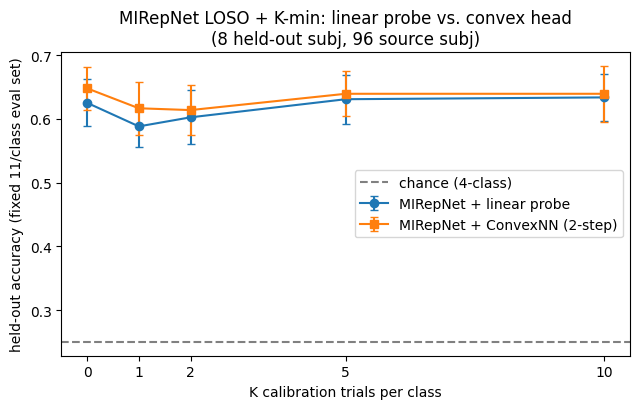

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.errorbar(lin_summary["k"], lin_summary["acc_mean"], yerr=lin_summary["sem"],
            marker="o", capsize=3, label="MIRepNet + linear probe")
ax.errorbar(summary["k"], summary["acc_mean"], yerr=summary["sem"],
            marker="s", capsize=3, label="MIRepNet + ConvexNN (2-step)")
ax.axhline(0.25, ls="--", color="grey", label="chance (4-class)")
ax.set_xlabel("K calibration trials per class")
ax.set_ylabel(f"held-out accuracy (fixed {EVAL_PER_CLASS}/class eval set)")
ax.set_title(f"MIRepNet LOSO + K-min: linear probe vs. convex head\n"
             f"({len(subject_splits)} held-out subj, {len(source_subjects)} source subj)")
ax.set_xticks(list(K_BUDGETS))
ax.legend()
fig.tight_layout()
fig.show()

comparison = lin_summary[["k", "acc_mean", "sem"]].rename(columns={"acc_mean": "linear_acc", "sem": "linear_sem"})
comparison = comparison.merge(
    summary[["k", "acc_mean", "sem"]].rename(columns={"acc_mean": "convex_acc", "sem": "convex_sem"}),
    on="k", how="outer")
comparison


## 9. Save artifacts

In [11]:
out_dir = REPO_ROOT / "results" / "mirepnet_kmin_nb"
out_dir.mkdir(parents=True, exist_ok=True)
stamp = time.strftime("%Y%m%d-%H%M%S")
lin_df.to_csv(out_dir / f"linear_per_split_{stamp}.csv", index=False)
lin_summary.to_csv(out_dir / f"linear_summary_{stamp}.csv", index=False)
df.to_csv(out_dir / f"convex_per_split_{stamp}.csv", index=False)
summary.to_csv(out_dir / f"convex_summary_{stamp}.csv", index=False)
comparison.to_csv(out_dir / f"comparison_{stamp}.csv", index=False)
print("wrote:", out_dir)
comparison


wrote: /Users/williamtan/Projects/cs229/etm_clf/results/mirepnet_kmin_nb


,k,linear_acc,linear_sem,convex_acc,convex_sem
0,0,0.625000,0.036697,0.647727,0.033269
1,1,0.588068,0.032267,0.616477,0.041517
2,2,0.602273,0.042083,0.613636,0.039831
3,5,0.630682,0.038356,0.639205,0.035532
4,10,0.633523,0.036807,0.639205,0.043682
